# Rule Based Segmentation

In this notebook we segment users based on defined rules and their features.
Here the segmentation is not mutually exclusive, as a user can belong to multiple segments. The perk assignment notebook will care for choosing one most interesting perk to the customer.

## Bootstrap
Configuring parameters, loading libraries and dataset.

In [99]:
import sys, os
# This line allows us to import from the parent directory, which is where the 'src' folder is located.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
# These lines enable automatic reloading of modules in Jupyter, so that changes to the code are reflected without needing to restart the kernel.
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Libraries
External

In [100]:
!pip install scikit-learn

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import math as math

Project libraries

In [102]:
from src.utils import Config
from src.profile import Profiler

### Configuration
Set here general paramenters

In [103]:
config = Config({
    'datasets_path': '../data/aggregated/',
    'save_segmentation_to_path': '../data/segmented/users_rb.csv',
})

### Loading Datasets

In [104]:
users = pd.read_csv(f"{config.datasets_path}/users.csv")
# Remove datetime columns that are not useful for the profiling
cols_to_remove = ['birthdate', 'sign_up_date']
users = users.drop(columns=cols_to_remove)

## Segmentation
In this section we define segments based on user's characteristics and properties, then we evaluate the profile of users in that segment, trying to find patters that show what kind perk could be atractive to them.

In [105]:
def show_segment(condition):
    segment = users[condition]
    remaining = users[~condition]

    print(f"Segment size: {len(segment)} users ({len(segment) / len(users):.2%} of total)")
    profiler = Profiler(segment, remaining)
    display(profiler.to_dataframe())
    profiler.plot_profile()

### 1. High-Value Customers

**Goal:** Give premium perks, priority support.

**Perks:** 
* Priority support
* Free upgrades / seat selection
* Free checked bag

Segment size: 2012 users (33.54% of total)


,cohen_d,mean_segment,mean_remaining,lift
total_trips,1.866683,4.061133,1.971400,1.060025
hotel_bookings,1.813946,3.711233,1.716508,1.162083
flight_bookings,1.502048,3.498509,1.656046,1.112567
total_hotel_nights,1.491338,16.310139,6.354491,1.566711
combo_bookings,1.469611,3.148608,1.402910,1.244341
return_flight_bookings,1.428209,3.277336,1.480181,1.214146
total_hotel_amount,1.217997,3723.387674,1250.726292,1.976980
weekdays_travelled,0.829091,10.104374,5.282489,0.912806
weekends_travelled,0.762011,4.078529,2.124686,0.919591
total_distance_flown,0.742424,7668.150608,4103.441460,0.868712


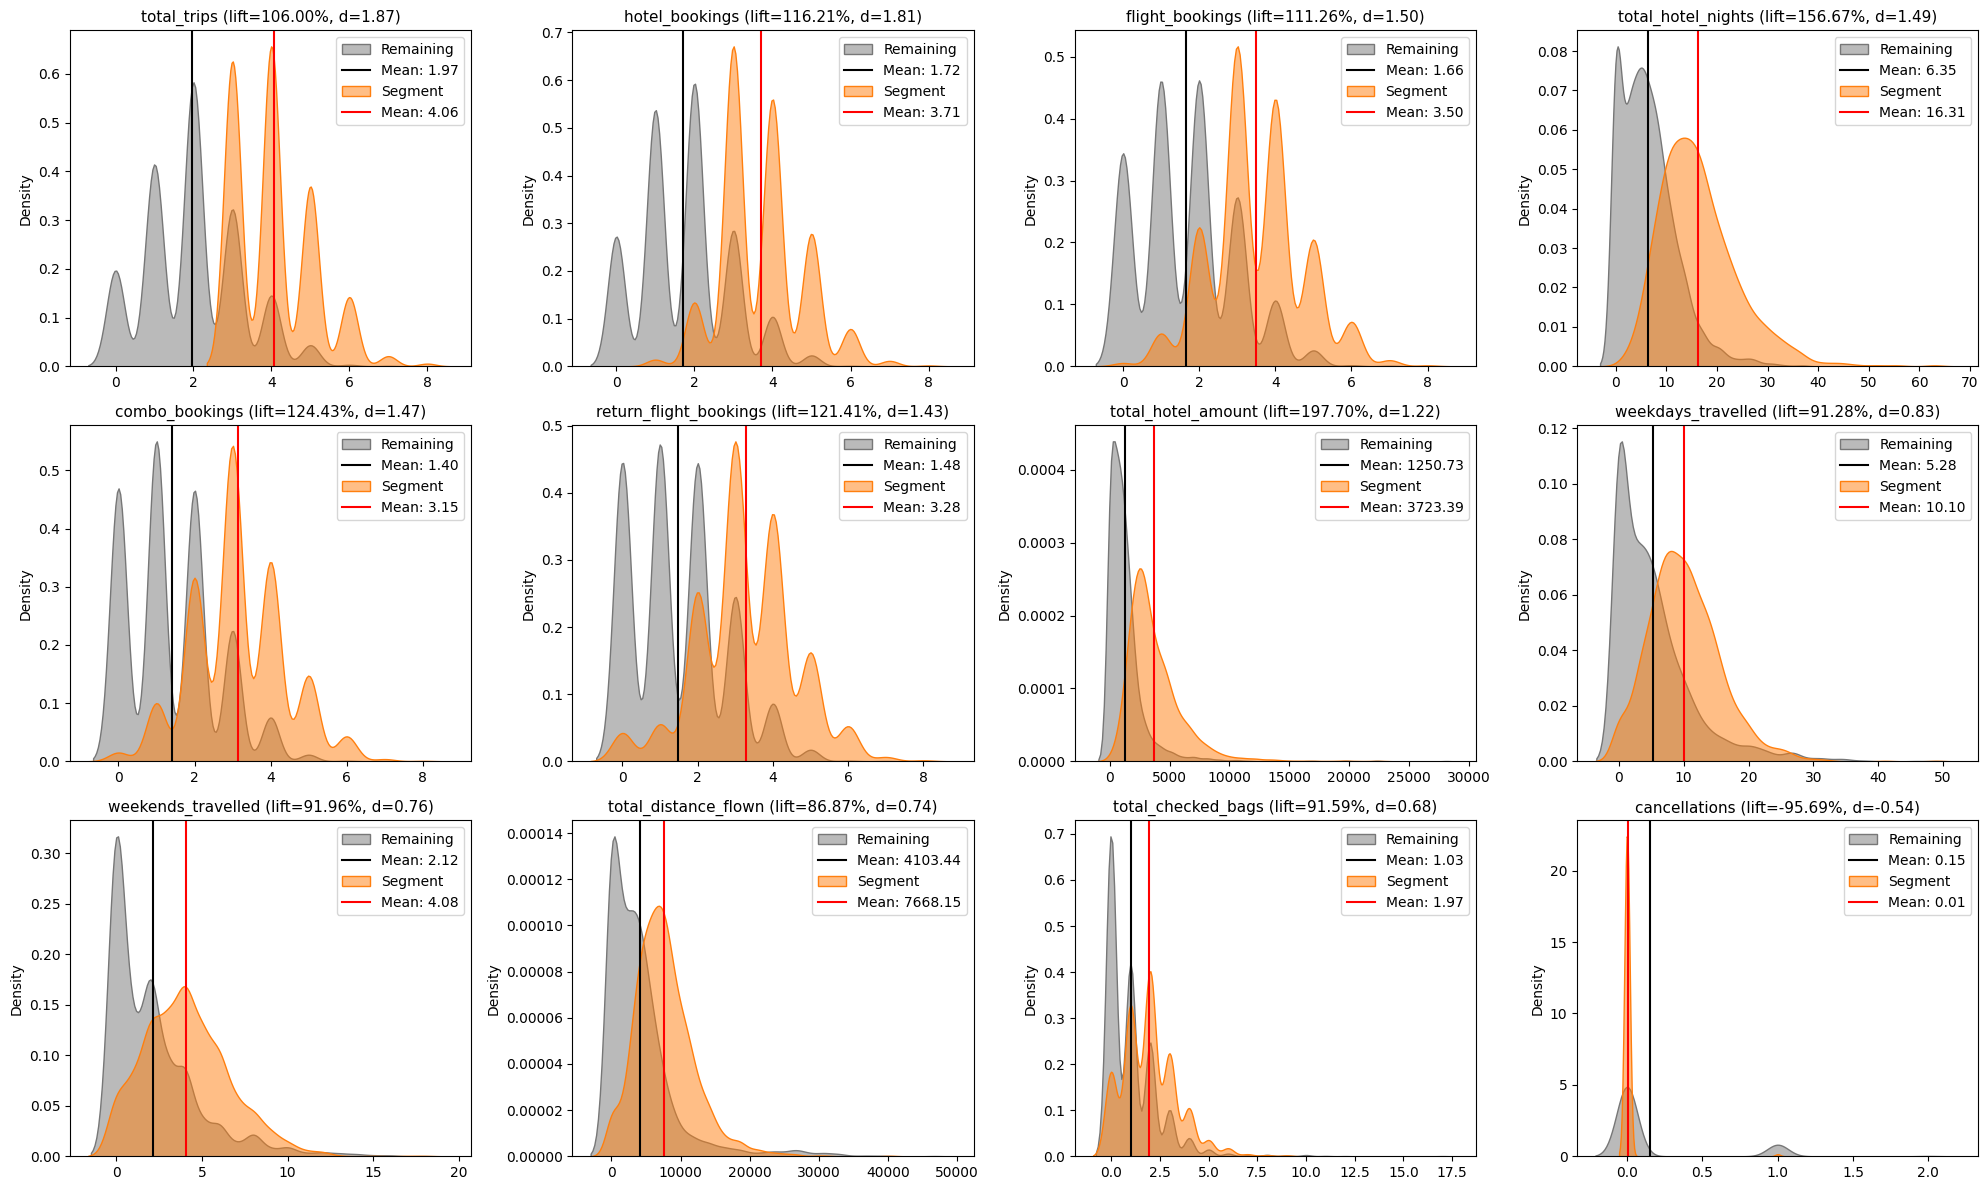

In [106]:
HIGH_VALUE_THRESHOLD = 3000
high_value_customers = (
    (users.total_flight_amount + users.total_hotel_amount >= HIGH_VALUE_THRESHOLD) &
    (users.total_trips >= 3) &
    (users.cancellations / users.total_trips < 0.2)
)
show_segment(high_value_customers)

### 2. Frequent Travelers

**Goal:** Reward consistency, increase lifetime value.

**Perks:**
 * Loyalty program boosts (e.g. more miles reward per flight)
 * Trip-based rewards (e.g. book 5 get 1 for free)

Segment size: 704 users (11.74% of total)


,cohen_d,mean_segment,mean_remaining,lift
total_trips,3.131017,5.329545,2.319040,1.298168
hotel_bookings,2.577441,4.779830,2.067246,1.312173
flight_bookings,2.518577,4.725852,1.948054,1.425934
combo_bookings,2.150319,4.177557,1.697393,1.461160
return_flight_bookings,1.840753,4.272727,1.791840,1.384548
total_hotel_nights,1.322648,18.498580,8.523234,1.170371
weekdays_travelled,1.074086,12.799716,6.115414,1.093025
total_distance_flown,1.008944,9851.808489,4693.797413,1.098899
weekends_travelled,0.982551,5.164773,2.462977,1.096963
total_checked_bags,0.939420,2.593750,1.179260,1.199473


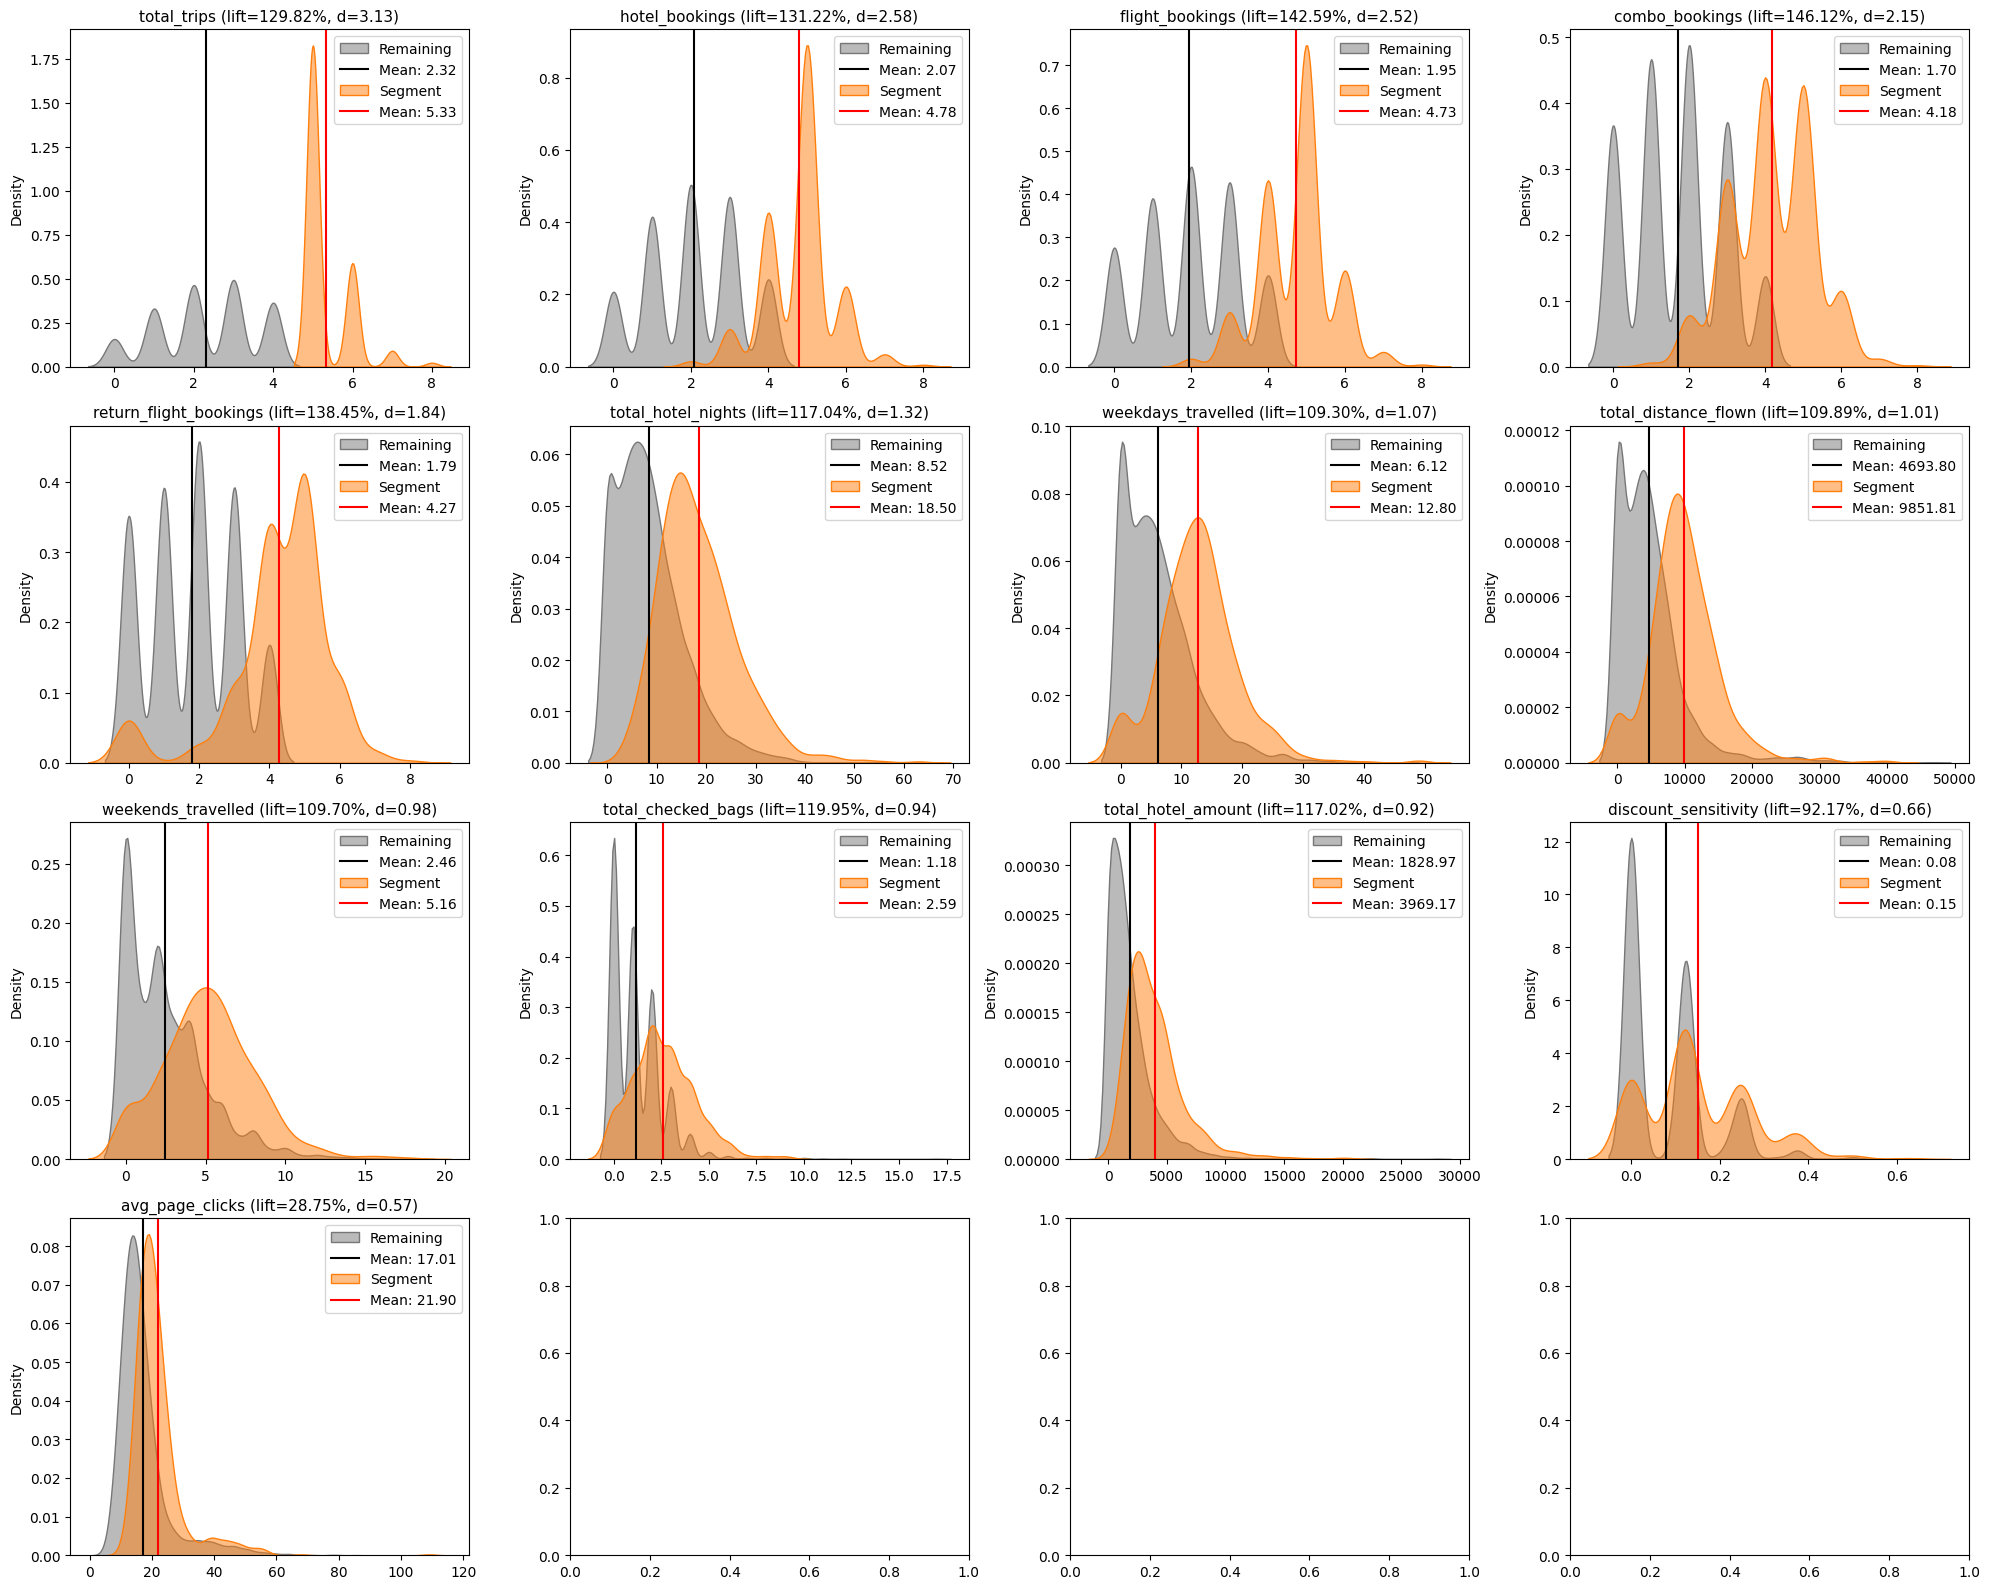

In [107]:
frequent_travelers = (
    (users.total_trips >= 5) &
    (users.account_age >= 2)
)
show_segment(frequent_travelers)

### 3. Price-Sensitive Users

**Goal:** Convert via targeted deals, aoid over-subsidizing.

**Perks:**
 * Time-limited discounts
 * Bundled offers (flight+hotel discount)

Segment size: 521 users (8.69% of total)


,cohen_d,mean_segment,mean_remaining,lift
discount_sensitivity,1.237353,0.190827,0.076578,1.491919
avg_cents_km_flown,-0.752015,17.065004,21.672073,-0.212581
avg_seats_booked,-0.693176,1.010493,1.242537,-0.186751
total_trips,0.562676,3.387716,2.604345,0.300794
total_hotel_discount,0.546979,122.263724,28.469965,3.294481
hotel_bookings,0.544350,3.067179,2.320796,0.321606


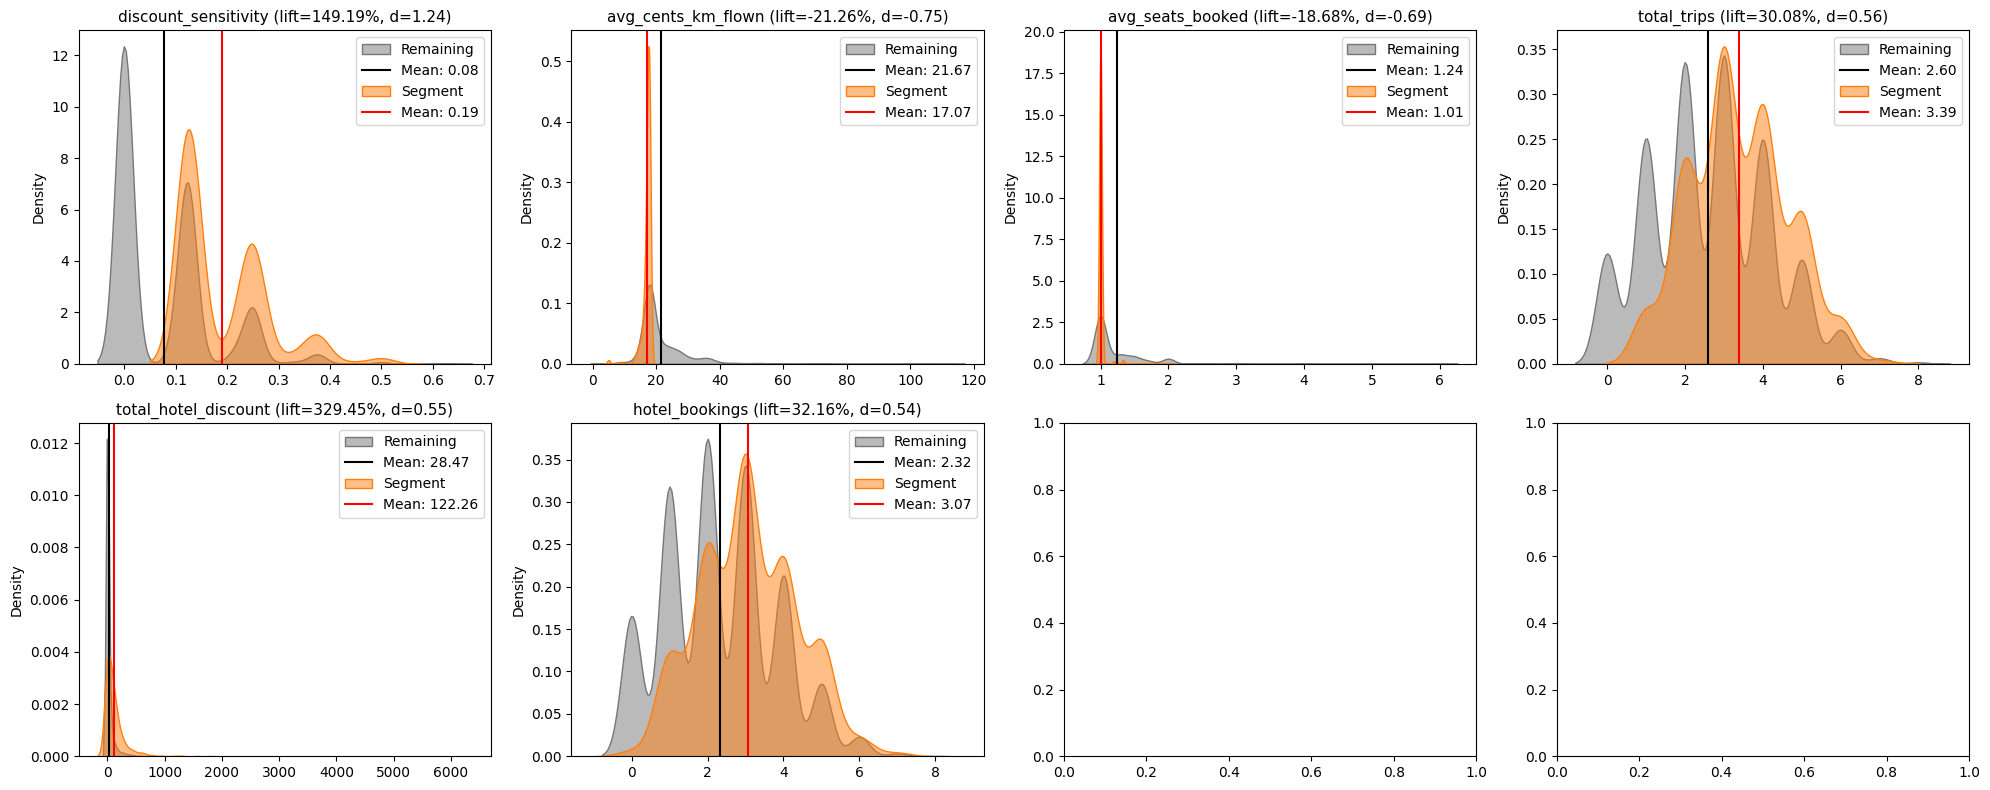

In [108]:
price_sensitive_travelers = (
    (users.discount_sensitivity > users.discount_sensitivity.median()) &
    ((users.avg_flight_discount > users.avg_flight_discount.median()) | (users.avg_hotel_discount > users.avg_hotel_discount.median())) &
    (users.avg_cents_km_flown < users.avg_cents_km_flown.median())
)
show_segment(price_sensitive_travelers)

### 4. Loyal Last-Minute Bookers

**Goal:** Improve or nudge earlier booking.

**Perks:**
 * Fast checkout
 * Discount for Business or 1st Class upgrade

Segment size: 323 users (5.39% of total)


,cohen_d,mean_segment,mean_remaining,lift
total_trips,2.591313,5.328173,2.521233,1.113320
hotel_bookings,2.277294,4.842105,2.245815,1.156057
flight_bookings,2.106101,4.690402,2.136564,1.195302
combo_bookings,1.896814,4.207430,1.862203,1.259384
return_flight_bookings,1.532763,4.207430,1.962115,1.144335
total_hotel_nights,1.208592,18.569659,9.188899,1.020880
total_hotel_amount,0.892119,4051.897833,1967.945022,1.058949
weekdays_travelled,0.875141,11.922601,6.614097,0.802604
weekends_travelled,0.841060,4.938080,2.657269,0.858329
total_distance_flown,0.828275,9150.846459,5079.984718,0.801353


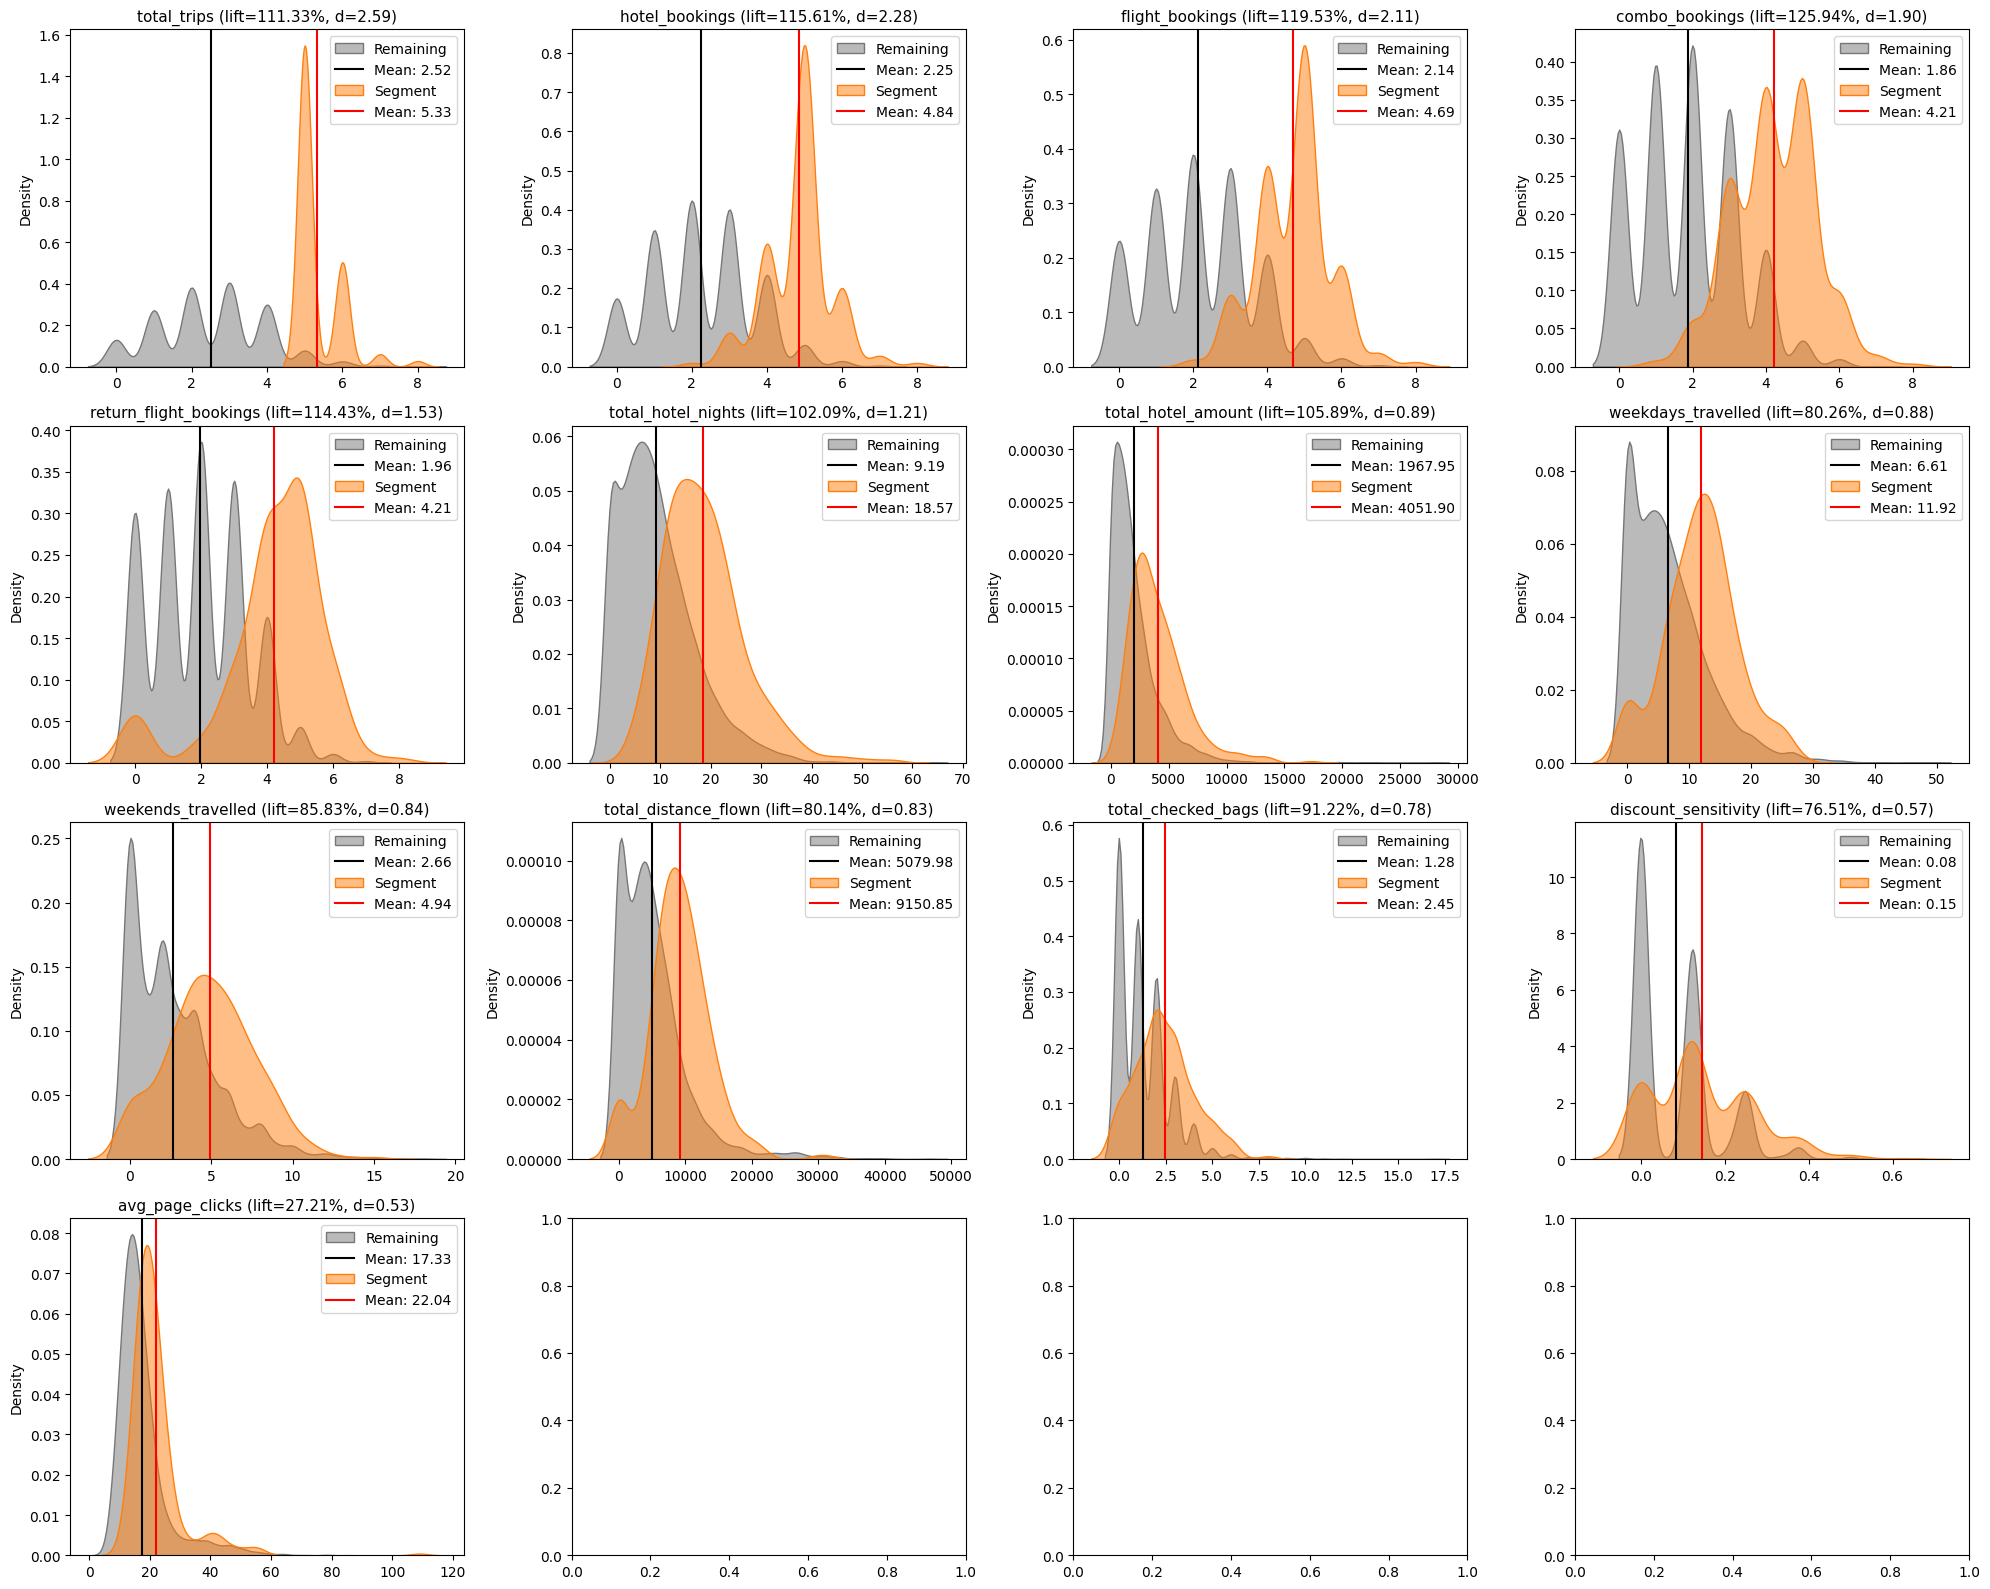

In [109]:
last_minute_bookers = (
    (users.avg_trip_lead_time < 7) &
    (users.total_trips >= 5)
)
show_segment(last_minute_bookers)

### 5. Family Vacationers

**Goal:** Bundle and convenience perks.

**Perks**:
 * Family bundle discounts
 * Free seat selection together
 * Free breakfast
 * Free extra bed

Segment size: 49 users (0.82% of total)


,cohen_d,mean_segment,mean_remaining,lift
avg_seats_booked,3.325495,3.867347,1.191689,2.245264
avg_cents_km_flown,2.864339,67.537889,20.724914,2.258778
has_children,2.057151,1.000000,0.320894,2.116291
avg_checked_bags,2.031402,2.748299,0.579153,3.745381
avg_trip_duration,1.826893,10.281250,4.462634,1.303853
avg_trip_lead_time,1.734298,128.897279,16.732048,6.703616
total_checked_bags,1.683204,6.081633,1.306270,3.655724
married,1.199796,0.918367,0.436544,1.103723
avg_flight_amount,1.167731,20539.125102,745.345258,26.556525
cancellations,1.143076,0.571429,0.097832,4.840943


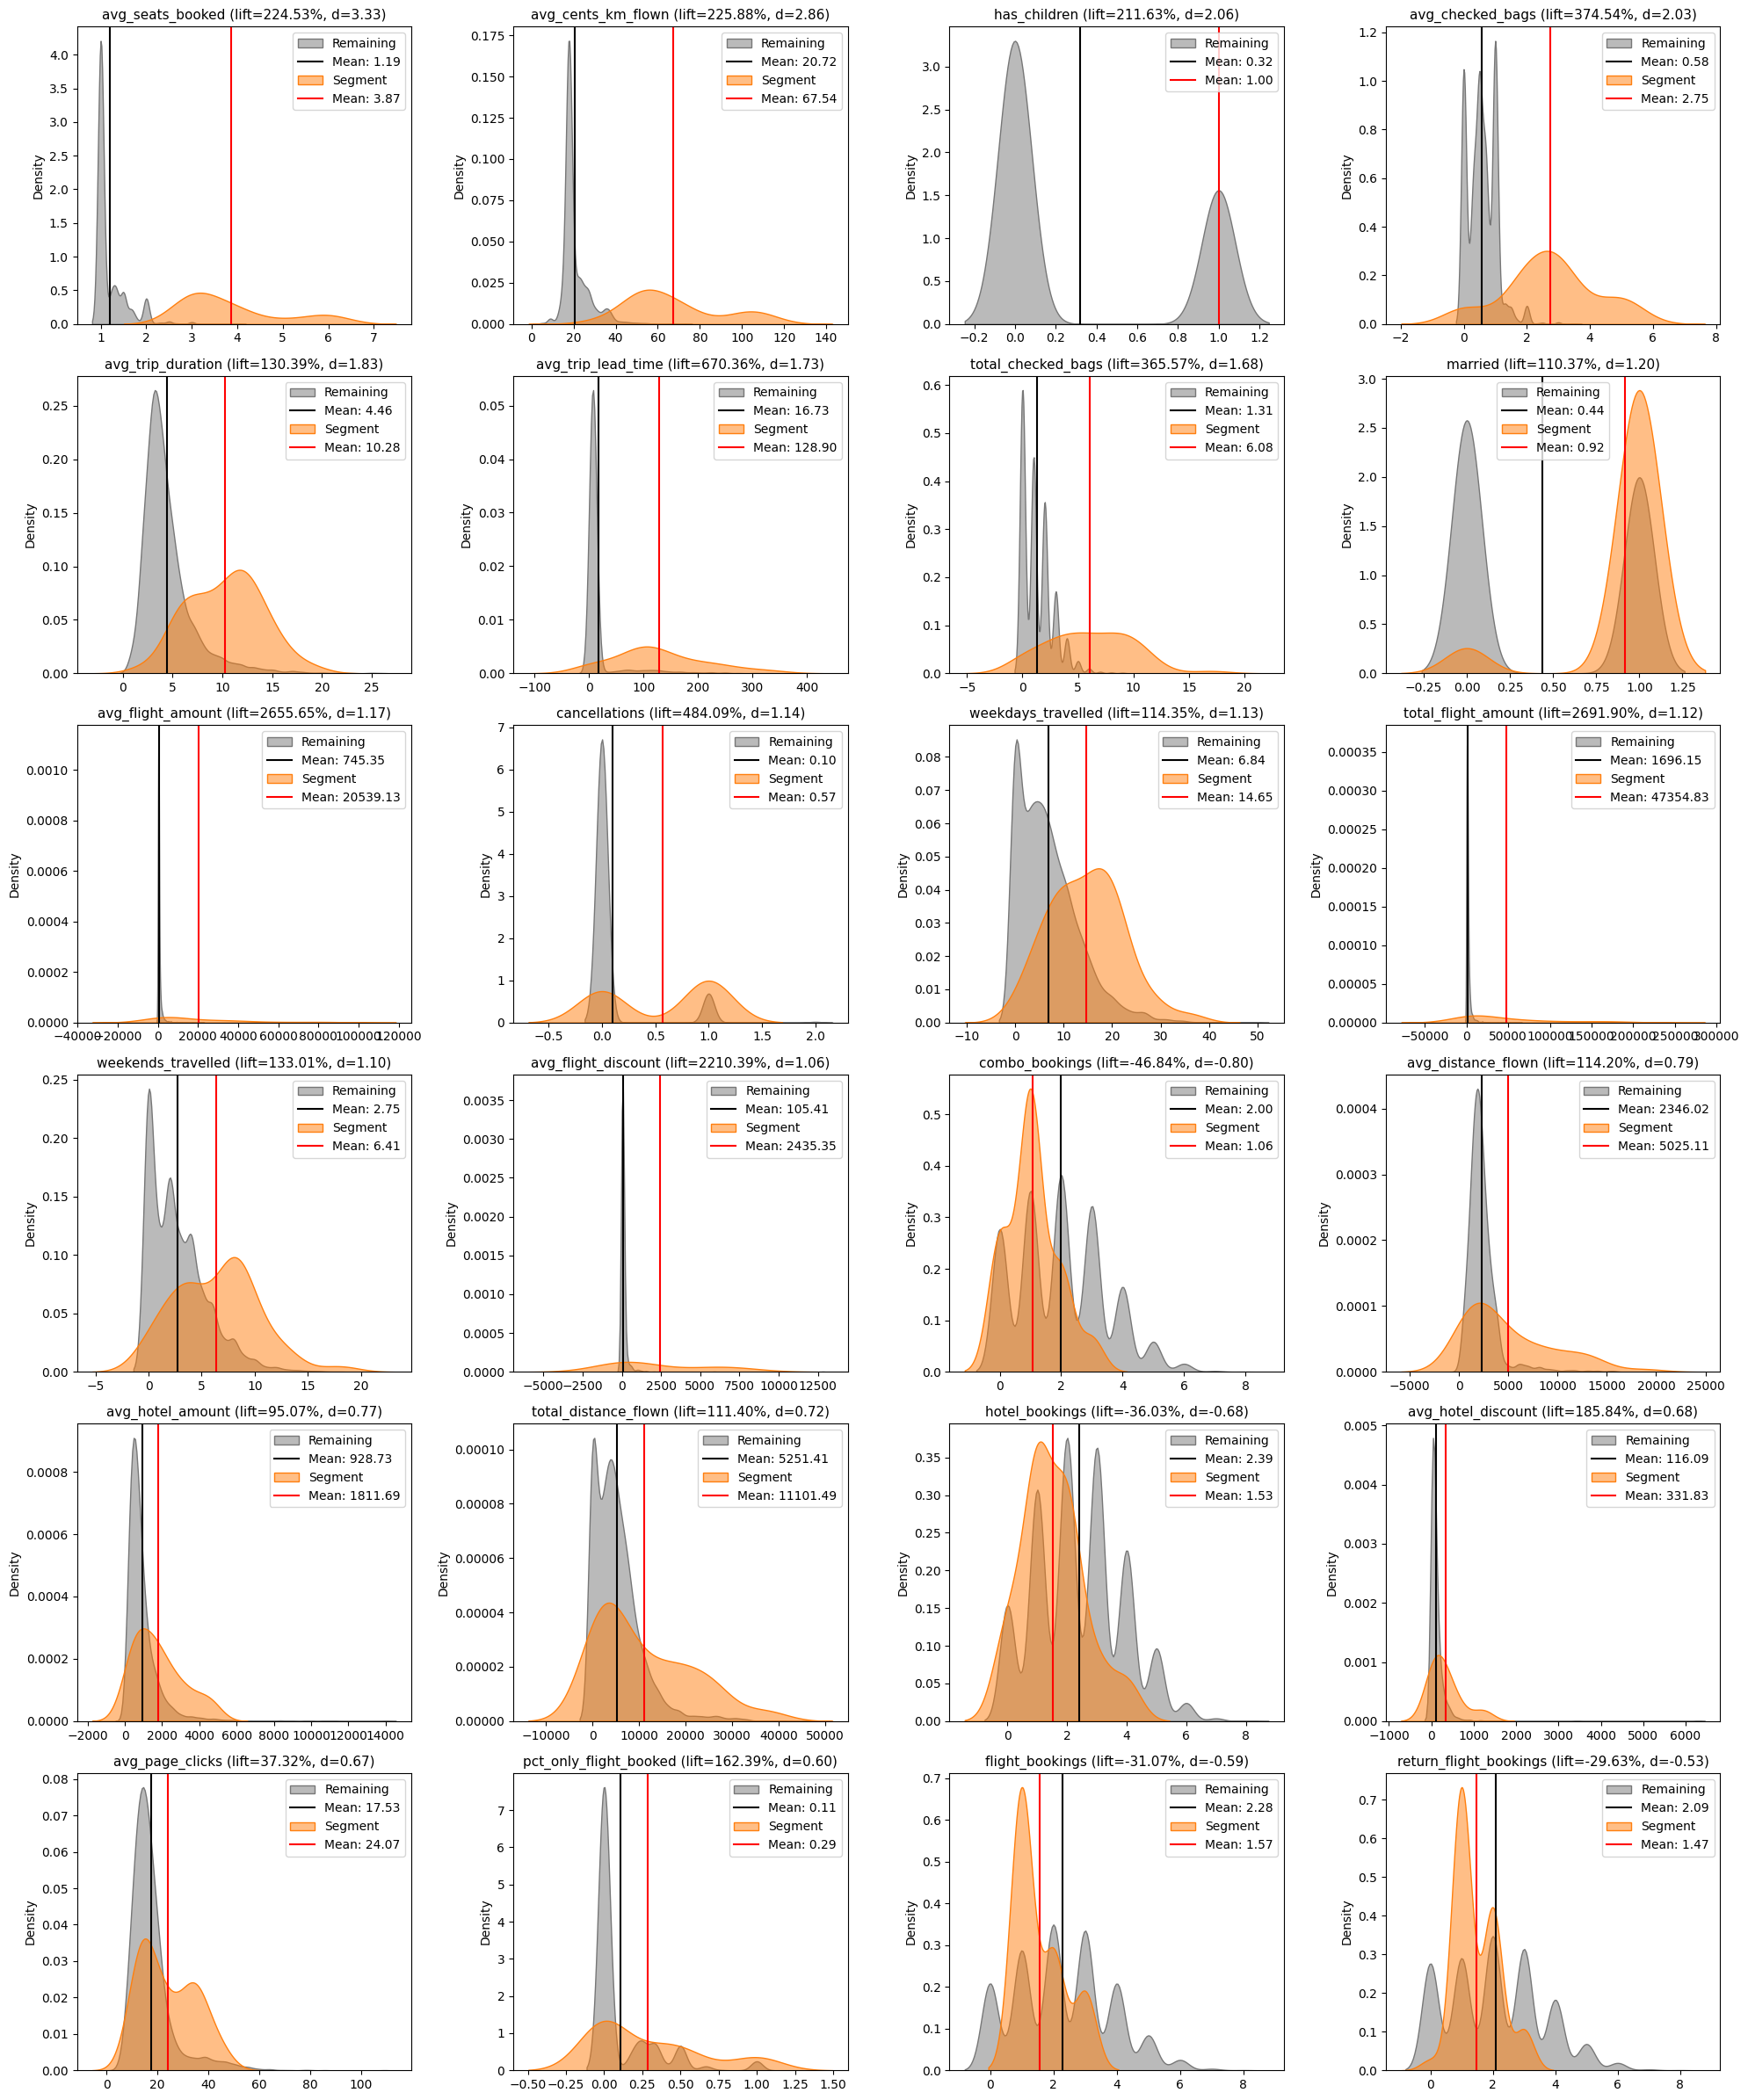

In [110]:
family_vacationers = (
    (users.has_children == 1) &
    (users.avg_seats_booked >= 3)
)

show_segment(family_vacationers)

### 6. Business Travelers

**Goal:** Speed and reliability perks

**Perks:**
 * Flexible changes
 * Priority Boarding
 * Fast refunds

Segment size: 334 users (5.57% of total)


,cohen_d,mean_segment,mean_remaining,lift
weekends_ratio,-2.678985,0.008845,0.305833,-0.971078
weekends_travelled,-1.453834,0.104790,2.937853,-0.964331
avg_trip_duration,-1.027975,2.573054,4.661936,-0.448072
pct_return_flight_booked,0.507572,0.999501,0.911102,0.097024


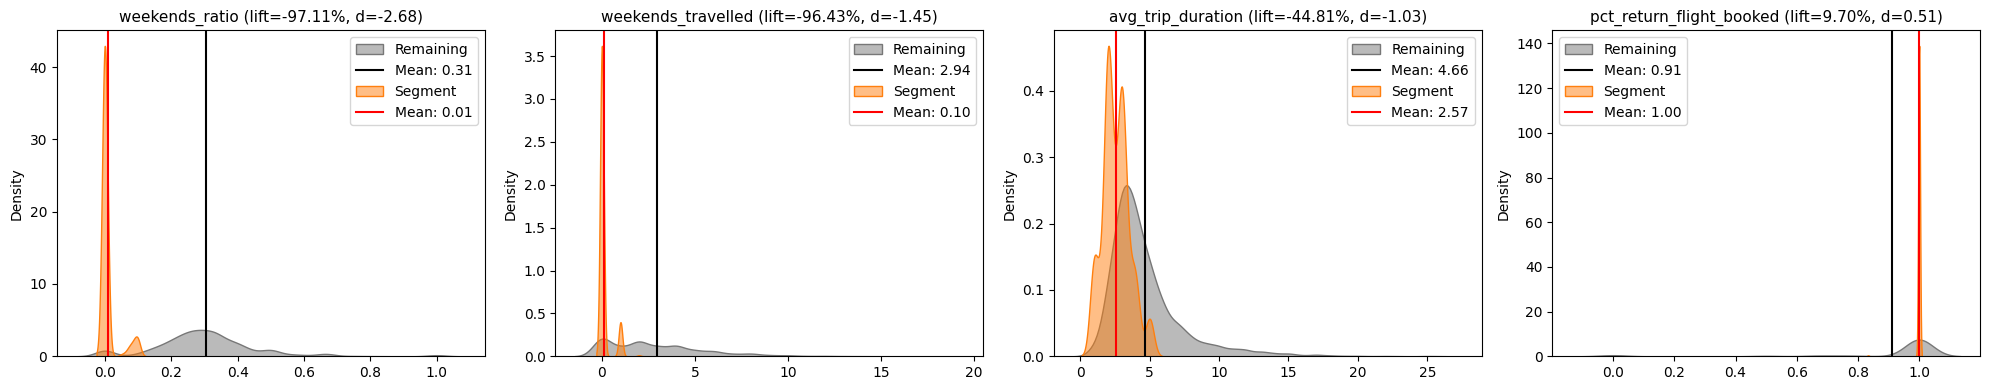

In [111]:
business_travelers = (
    (users.weekends_ratio <= 0.1) &
    (users.avg_trip_lead_time <= 7) &
    (users.pct_return_flight_booked >= 0.8)
)
show_segment(business_travelers)

### 7. Leisure Travelers

**Goal:** Inspire upgrades and packages

**Perks:**
 * Hotel upgrades
 * Activity recommendations
 * Free checked bag

Segment size: 195 users (3.25% of total)


,cohen_d,mean_segment,mean_remaining,lift
weekends_ratio,1.583933,0.468154,0.278034,0.683800
weekends_travelled,0.751999,4.692308,2.715837,0.727758


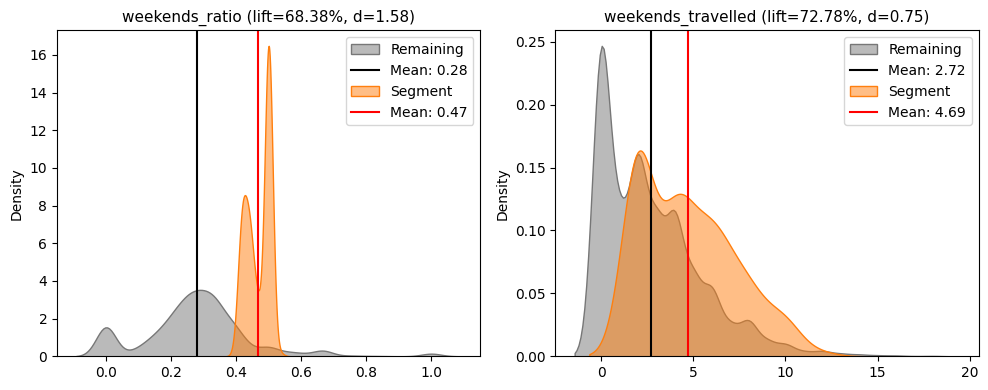

In [112]:
leisure_travelers = (
    (users.weekends_ratio > 0.4) &
    (users.avg_trip_duration >= 4)
)
show_segment(leisure_travelers)

### 8. Flight-Only Users

**Goal:** Increase cross-sell hotels

**Perks:**
 * Hotel discounts
 * Free night in hotel

Segment size: 136 users (2.27% of total)


,cohen_d,mean_segment,mean_remaining,lift
pct_only_flight_booked,7.483057,0.996324,0.088153,10.302184
hotel_bookings,-2.411222,0.000000,2.440976,-1.000000
combo_bookings,-2.021227,0.000000,2.034630,-1.000000
total_hotel_nights,-1.795893,0.000000,9.918970,-1.000000
total_trips,-1.450288,1.117647,2.708461,-0.587350
total_hotel_amount,-1.340487,0.000000,2128.429034,-1.000000
avg_trip_lead_time,1.104014,105.829657,15.506584,5.824821
flight_bookings,-1.087564,1.110294,2.301092,-0.517492
return_flight_bookings,-0.958676,1.044118,2.107131,-0.504484
pct_only_hotel_booked,-0.878504,0.000000,0.178261,-1.000000


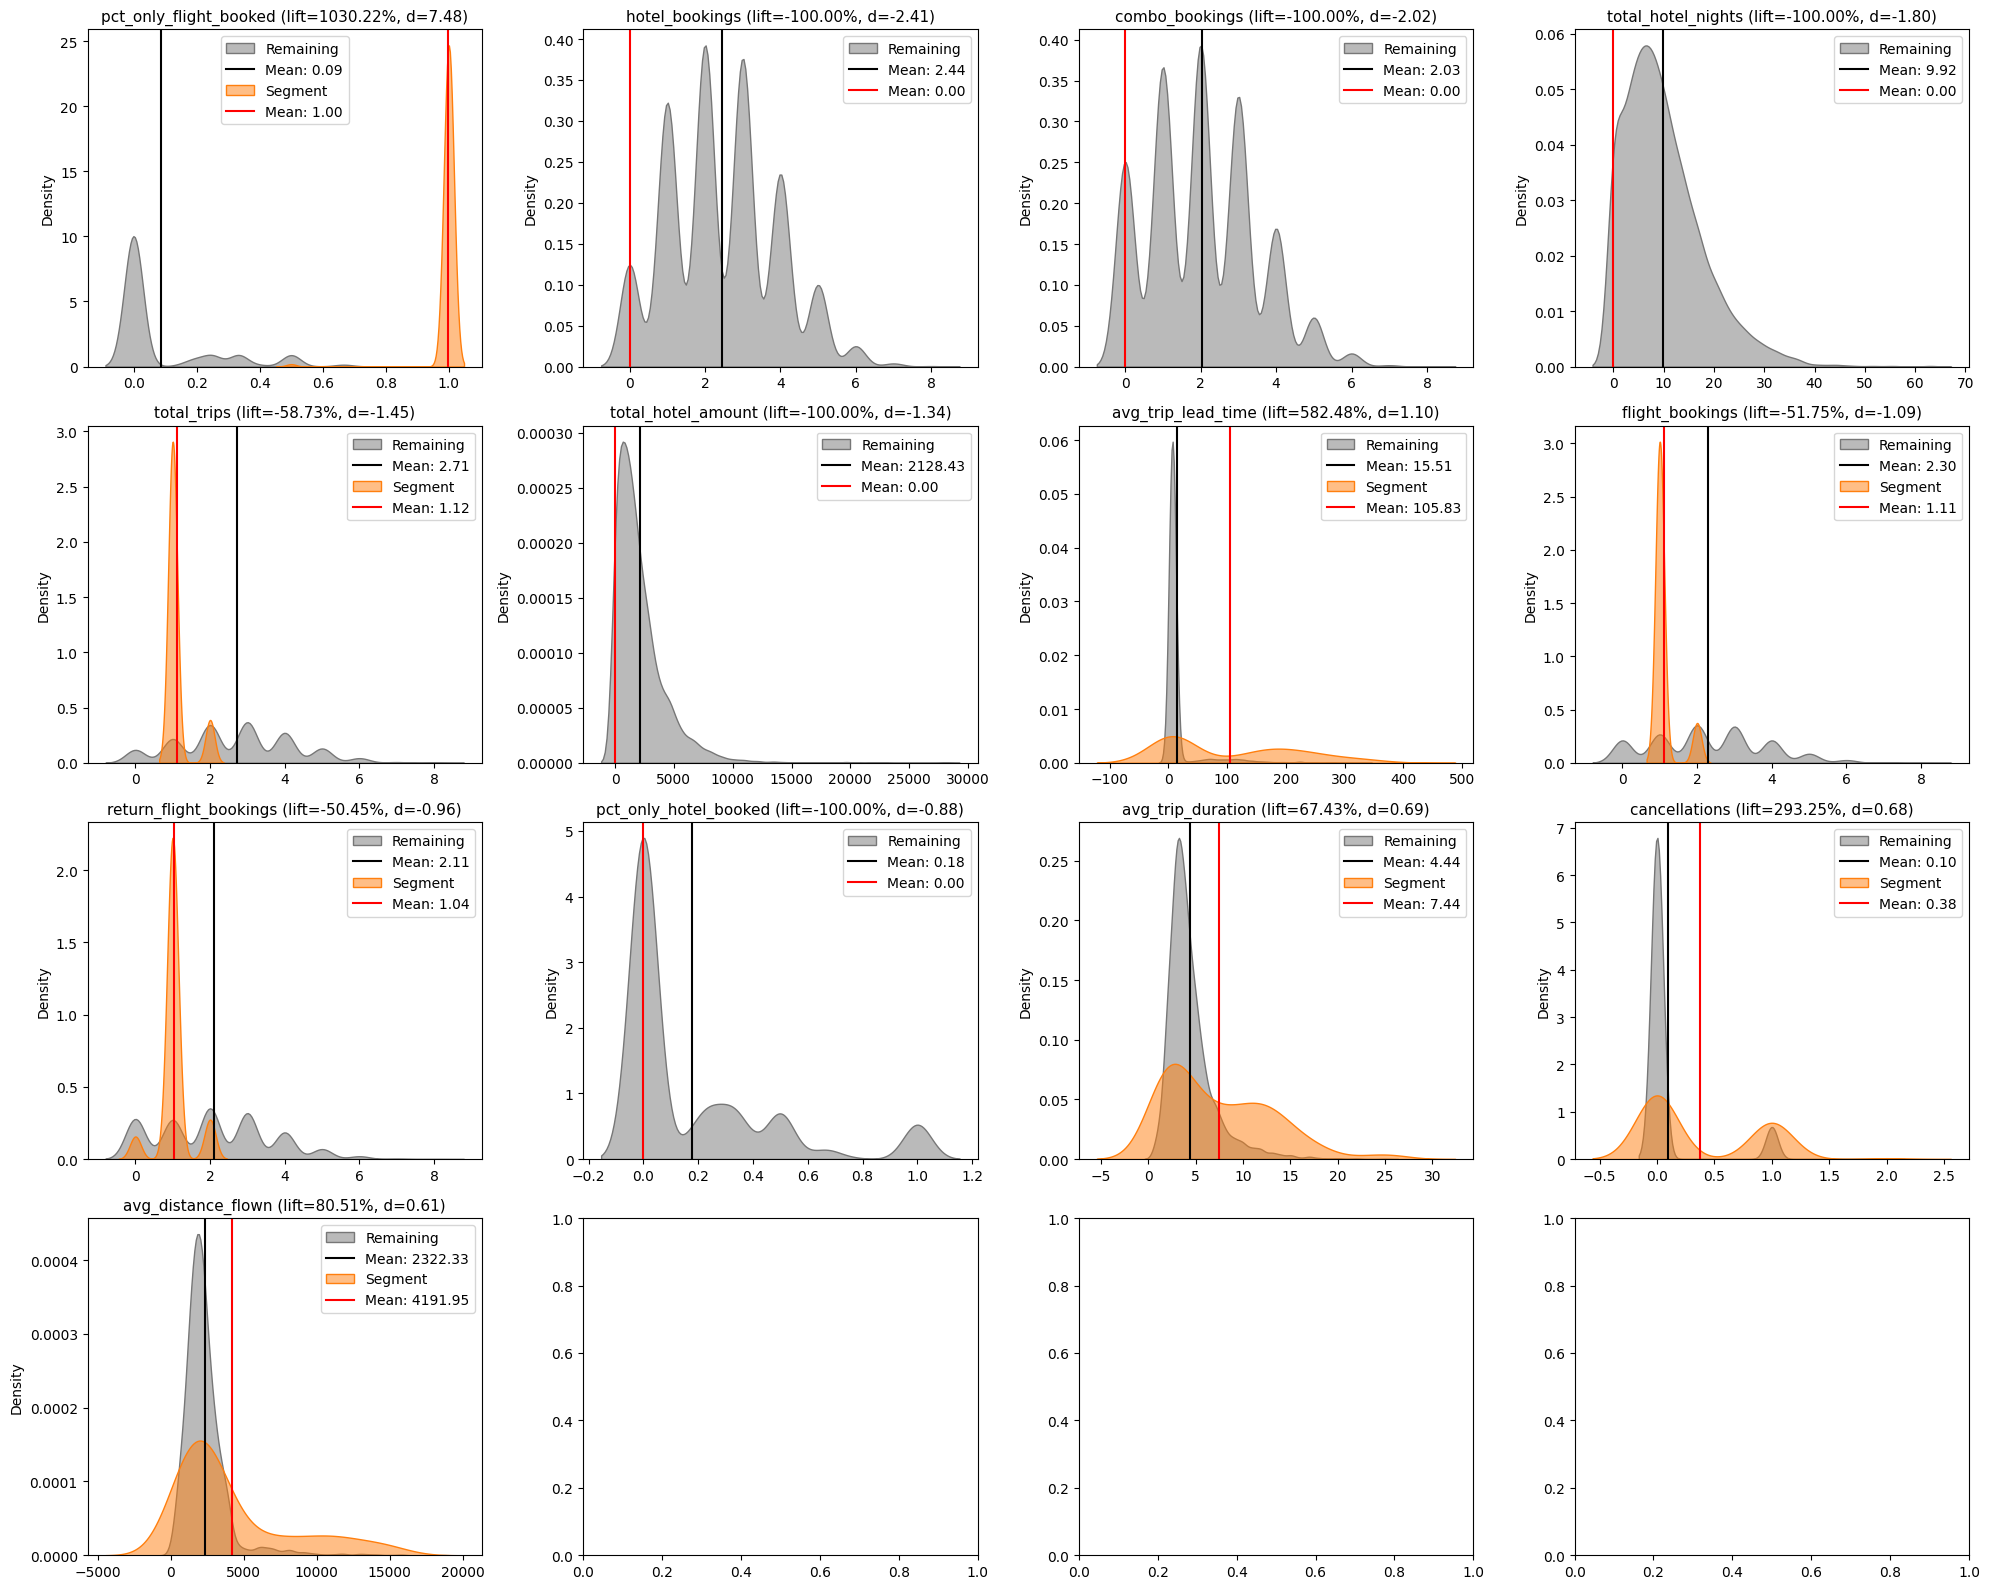

In [113]:
flight_only_users = (
    (users.flight_bookings > 0) &
    (users.hotel_bookings == 0)
)
show_segment(flight_only_users)

## Segment Assignment

In this section we assign the segment to each user.

In [115]:
segmnents = {
    'high_value_customers': high_value_customers,
    'frequent_travelers': frequent_travelers,
    'price_sensitive_travelers': price_sensitive_travelers,
    'last_minute_bookers': last_minute_bookers,
    'family_vacationers': family_vacationers,
    'business_travelers': business_travelers,
    'leisure_travelers': leisure_travelers,
    'flight_only_users': flight_only_users,
}
users['segment'] = ''  # Initialize the 'segment' column with empty strings
for segment, rows in segmnents.items():
    users.loc[rows, 'segment'] = np.where(users.loc[rows, 'segment'] == '', segment, users.loc[rows, 'segment'] + ',' + segment)

users.to_csv(config.save_segmentation_to_path, index=False)
print("Segmentation saved to:", config.save_segmentation_to_path)

Segmentation saved to: ../data/segmented/users_rb.csv


In [116]:
for segment in segmnents.keys():
    print(f"'{segment}',")

'high_value_customers',
'frequent_travelers',
'price_sensitive_travelers',
'last_minute_bookers',
'family_vacationers',
'business_travelers',
'leisure_travelers',
'flight_only_users',
